#Dataset Íris

O conjunto de dados Iris contém medidas de 150 flores de íris de três espécies diferentes: setosa, versicolor e virginica. As medidas incluem:

• sepal_length: comprimento da sépala

• sepal_width: largura da sépala

• petal_length: comprimento da pétala

• petal_width: largura da pétala

Esse dataset é frequentemente usado para tarefas de classificação, onde o objetivo é prever a espécie da íris com base em suas medidas. No entanto, também pode ser usado para tarefas de regressão, onde o objetivo é prever uma das medidas (por exemplo, petal_length) com base nas outras.

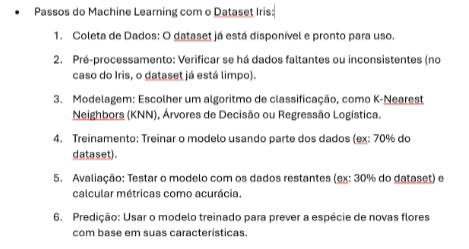

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_iris

# Carregar os dados
iris = load_iris()
iris

In [ ]:
df = pd.DataFrame(iris.data, iris.target, columns=iris.feature_names)
df['species'] = iris.target #iris.target_names[iris.target]
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
0,4.9,3.0,1.4,0.2,0
0,4.7,3.2,1.3,0.2,0
0,4.6,3.1,1.5,0.2,0
0,5.0,3.6,1.4,0.2,0


In [ ]:
# Quantidade de amostras e caractericas em cada
[amostra, caract] = iris.data.shape
print("Quantidade de amostras:", amostra, "\nQuantidade de caracteristicas em cada amostra: ", caract)

Quantidade de amostras: 150 
Quantidade de caracteristicas em cada amostra:  4


In [ ]:
# Quantidade de classes(especies)
especies = iris.target_names
print("Quantidade de classes (espécies): ", len(especies))

Quantidade de classes (espécies):  3


In [ ]:
X = iris.data  # Caracteristicas (features)
y = iris.target   # Rotulos (labels)

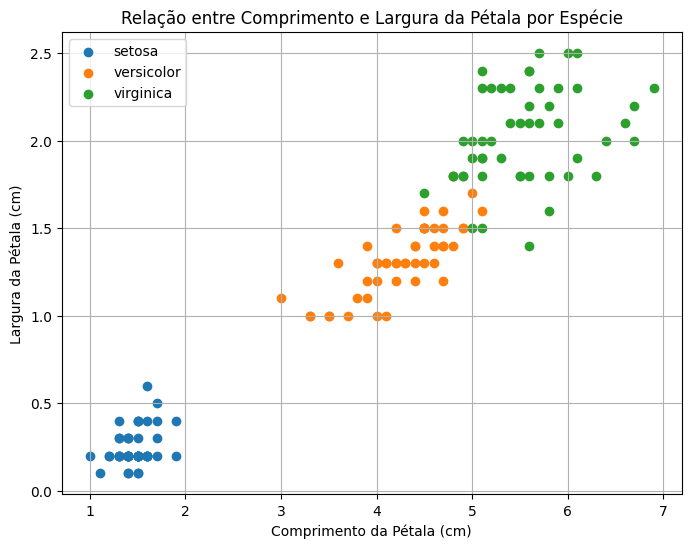

In [ ]:
# Grafico de dispersao da relação entre comprimento e largura da petala
import matplotlib.pyplot as plt

# Criar o gráfico de dispersão
plt.figure(figsize=(8, 6))
for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'], label=iris.target_names[species])

plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Largura da Pétala (cm)')
plt.title('Relação entre Comprimento e Largura da Pétala por Espécie')
plt.legend()
plt.grid(True)
plt.show()

Com base na visualização do gráfico, a espécie setosa é a mais facilmente sepáravel do restante das outras duas espécies.

##### Objetivo 1: Construir um modelo de regressão linear para prever o comprimento da pétala (comprimento_petala) com base nas outras medidas. Mostrar os resultados de forma tabular e as métricas RMSE E R2.

In [ ]:
# Carregar os dados
dados = load_iris()
df = pd.DataFrame(dados.data, columns=dados.feature_names)

# Separar as variáveis independentes (X) e dependente (y)
# X = iris.data[:, :-1]  # Todas as colunas exceto a última
# y = iris.data[:, -1]   # Última coluna (comprimento da pétala)
X = df[['comprimento_sepala', 'largura_sepala', 'largura_petala']]
y = df['comprimento_petala']


# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Criar um modelo de regressão linear
model = LinearRegression()


# Treinar o modelo usando os dados de treinamento
model.fit(X_train, y_train)


# Fazer previsões usando os dados de teste
y_pred = model.predict(X_test)


# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)


# Mostrar os resultados
print("Métricas do Modelo de Regressão Linear:")
print("--------------------------------------")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")
print(f"R²: {r2:.2f}")


# Mostrar os resultados em uma tabela
results = pd.DataFrame({'Comprimento da Pétala Real': y_test, 'Comprimento da Pétala Predito': y_pred})
print("\nResultados da Previsão:")
print(results.head())

##### Objetivo 2: Construir um modelo de classificação para prever a espécie da flor (Iris-setosa, Iris-versicolor, Iris-virginica) com base nas medidas da sépala e da pétala.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# Carregar dados
df = pd.read(opens in a new tab)_csv("/content/drive/MyDrive/Dataset_Python/IrisDataset.csv")


# Separar features e target
X = df.drop('especie', axis=1)
y = df['especie']


# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Criar e treinar o modelo KNN (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(opens in a new tab)(X_train, y_train)


# Fazer previsões
y_pred = knn.predict(X_test)


# Mostrar os resultados em uma tabela
results = pd.DataFrame({'Especie de Flor Real': y_test, 'Especie de flor Predita': y_pred})
print("\nResultados da Previsão:")
print(results.head())


# Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo KNN: {accuracy * 100:.2f}%")